In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load and Merge Data

In [17]:
# Load your datasets
movies = pd.read_csv("data/movies.csv")
ratings = pd.read_csv("data/ratings.csv")
tags = pd.read_csv("data/tags.csv")
links = pd.read_csv("data/links.csv")

# Step 1: Merge ratings with movie titles and genres
# We use a left join on 'ratings' so we don't lose any rating data
df = pd.merge(ratings, movies, on='movieId', how='left')

# Step 2: Merge with tags (optional, but good for content-based features)
# This will result in many rows if a movie has multiple tags
df = pd.merge(df, tags, on=['userId', 'movieId'], how='left', suffixes=('', '_tag'))

df.head()

,userId,movieId,rating,timestamp,title,genres,tag,timestamp_tag
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,NaN,NaN
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance,NaN,NaN
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller,NaN,NaN
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,NaN,NaN
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,NaN,NaN


In [19]:
df = df.drop(["timestamp","timestamp_tag"],axis=1)

In [20]:
df.shape

(102677, 6)

In [21]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 102677 entries, 0 to 102676
Data columns (total 6 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   userId   102677 non-null  int64  
 1   movieId  102677 non-null  int64  
 2   rating   102677 non-null  float64
 3   title    102677 non-null  str    
 4   genres   102677 non-null  str    
 5   tag      3476 non-null    str    
dtypes: float64(1), int64(2), str(3)
memory usage: 4.7 MB


In [22]:
df.tag = df.tag.fillna("")
df.head()

,userId,movieId,rating,title,genres,tag
0,1,1,4.0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,
1,1,3,4.0,Grumpier Old Men (1995),Comedy|Romance,
2,1,6,4.0,Heat (1995),Action|Crime|Thriller,
3,1,47,5.0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,
4,1,50,5.0,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,


### Data Insight: Genre Distribution

This visualization highlights the genre distribution across the entire movie catalog. A clear imbalance exists, with Drama and Comedy being the most prevalent categories, while niche genres like Film-Noir and Documentary are significantly less represented. This insight is critical for understanding potential bias in the recommendation engine, which may lean toward popular, mainstream genres by default.

Text(0, 0.5, 'Genre')

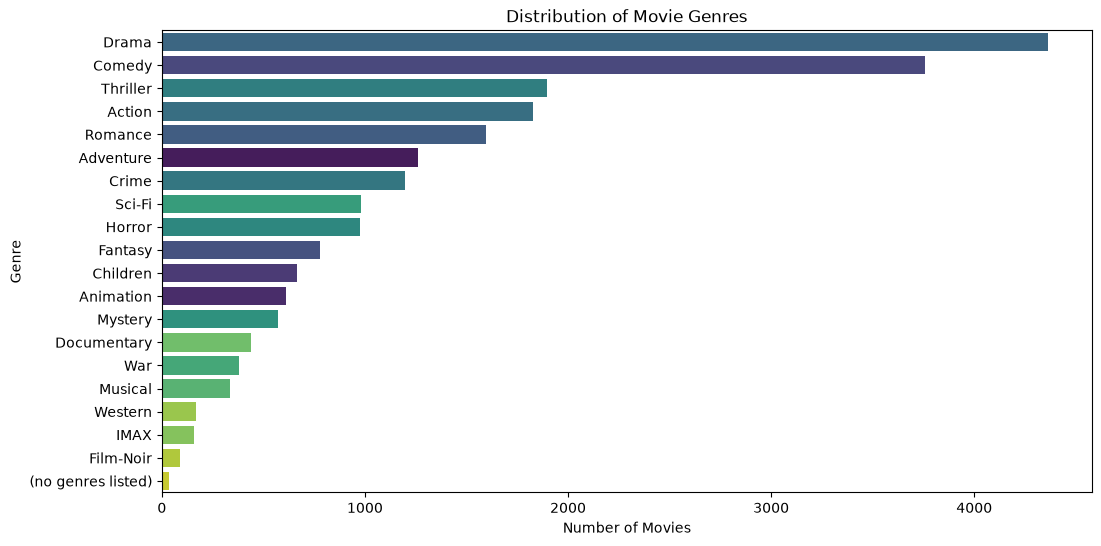

In [28]:
# 1. Prepare data for plotting
# Genres are pipe-separated; we need to explode them to count individual genres
genres_df = movies.assign(genres=movies['genres'].str.split('|')).explode('genres')

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.countplot(
    data=genres_df, 
    y='genres', 
    order=genres_df['genres'].value_counts().index, 
    hue='genres', 
    palette='viridis', 
    legend=False
)
plt.title('Distribution of Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')

### Strategic Implications

The "long tail" observed in this distribution confirms that our model must be designed to handle content sparsity. Because mainstream genres provide the strongest signals, we will need to implement specific weighting strategies or hybrid filtering techniques to ensure that recommendations remain diverse and that less frequent genres still surface when appropriate for a user's preferences.

### Data Insight: Rating Distribution

This histogram illustrates the distribution of user ratings across the dataset. We observe a clear skew toward higher scores, with 4.0 and 3.0 being the most frequently assigned ratings. The relative scarcity of ratings below 2.0 suggests that users are generally more likely to rate movies they enjoyed or found acceptable, rather than movies they disliked, which is a common characteristic of voluntary rating systems.

Text(0, 0.5, 'Count')

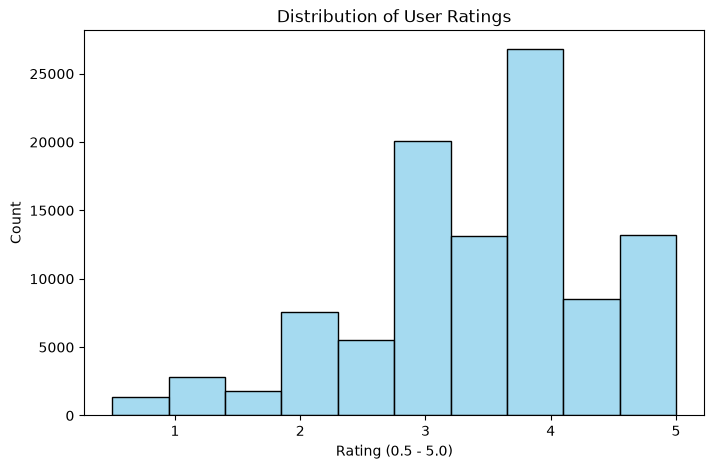

In [29]:
plt.figure(figsize=(8, 5))
sns.histplot(ratings['rating'], bins=10, kde=False, color='skyblue')
plt.title('Distribution of User Ratings')
plt.xlabel('Rating (0.5 - 5.0)')
plt.ylabel('Count')

### Strategic Implications

The positive skew in the rating distribution indicates that our recommendation model should be designed to handle "optimistic bias." Because users rarely assign low ratings, our model's performance should not be judged solely on accuracy, but also on its ability to distinguish between "good" (3.5–4.0) and "great" (4.5–5.0) content. Furthermore, the high frequency of 3.0, 3.5, and 4.0 ratings provides a strong baseline signal that will be the primary driver for our collaborative filtering approach.

### Data Sparsity & Distribution Analysis
The distribution of ratings per user and per movie reveals a classic "long-tail" phenomenon. A small subset of highly active users and popular movies dominates the dataset, while the vast majority of items and users have limited interaction history[cite: 1]. 

This imbalance is a crucial consideration for our recommendation strategy:
* **Collaborative Filtering** will be most effective for "popular" items with high rating counts.
* **Content-Based Filtering** (using genre and tag metadata) is essential to ensure that "long-tail" movies—which lack sufficient rating data—are still discoverable by the system.

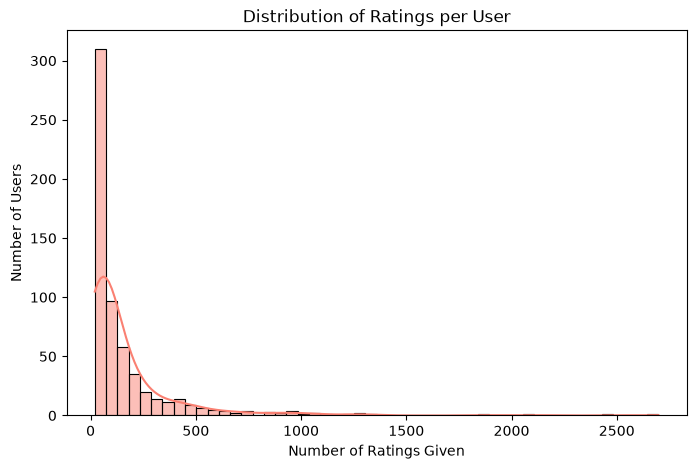

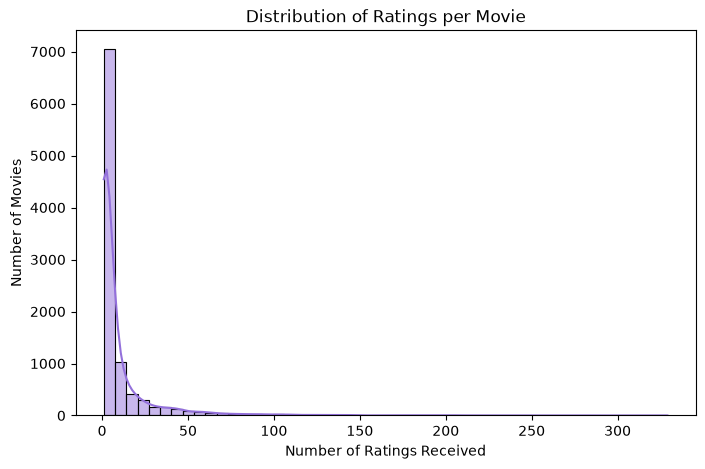

In [31]:
# 1. Distribution of Ratings per User
# This helps identify 'super-users' vs. 'casual-users'
user_activity = ratings['userId'].value_counts()

plt.figure(figsize=(8, 5))
sns.histplot(user_activity, bins=50, kde=True, color='salmon')
plt.title('Distribution of Ratings per User')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Number of Users')
plt.show()

# 2. Distribution of Ratings per Movie
# This highlights 'blockbuster' movies vs. 'long-tail' niche content
movie_popularity = ratings['movieId'].value_counts()

plt.figure(figsize=(8, 5))
sns.histplot(movie_popularity, bins=50, kde=True, color='mediumpurple')
plt.title('Distribution of Ratings per Movie')
plt.xlabel('Number of Ratings Received')
plt.ylabel('Number of Movies')
plt.show()